In [1]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
from matplotlib.colors import LinearSegmentedColormap

In [2]:
table_coarse_raw = dict()
table_middle_raw = dict()
table_fine_raw = dict()

with h5py.File("data/new_turbulence60kpc_withturb_right.h5", "r") as f:
    for key in f:
        table_coarse_raw[key] = np.array(f[key])

with h5py.File("data/new_turbulence30kpc_withturb_right.h5", "r") as f:
    for key in f:
        table_middle_raw[key] = np.array(f[key])

with h5py.File("data/new_turbulence15kpc_withturb_right.h5", "r") as f:
    for key in f:
        table_fine_raw[key] = np.array(f[key])


table_coarse = dict()
table_middle = dict()
table_fine = dict()

for key in table_coarse_raw:
    table_coarse[key] = table_coarse_raw[key][(table_coarse_raw["distGC"] < 1000) & (table_coarse_raw["distGC"] > 40)]

for key in table_middle_raw:
    table_middle[key] = table_middle_raw[key][(table_middle_raw["distGC"] < 1000) & (table_middle_raw["distGC"] > 40)]

for key in table_fine_raw:
    table_fine[key] = table_fine_raw[key][(table_fine_raw["distGC"] < 1000) & (table_fine_raw["distGC"] > 40)]

In [4]:
print(table_coarse.keys())

dict_keys(['CompressiveFraction', 'CompressiveFraction_turb', 'CompressiveMach_v', 'CompressiveMach_v_turb', 'DensityDisp_m', 'DensityDisp_v', 'DensityMean_m', 'DensityMean_v', 'LogDensityDispRadial_m', 'LogDensityDispRadial_v', 'LogDensityDisp_m', 'LogDensityDisp_v', 'LogPressureDispRadial_m', 'LogPressureDispRadial_v', 'LogPressureDisp_m', 'LogPressureDisp_v', 'Mach_m', 'Mach_m_turb', 'Mach_v', 'Mach_v_turb', 'MagneticFieldMean_m', 'MagneticFieldMean_v', 'MagneticPressMean_m', 'MagneticPressMean_v', 'MeanElectronAbundance_m', 'MeanElectronAbundance_v', 'MeanMolecularWeightMean_m', 'MeanMolecularWeightMean_v', 'PressureDisp _v', 'PressureDisp_m', 'PressureMean_m', 'PressureMean_v', 'SFR', 'SolenoidalFraction', 'SolenoidalFraction_turb', 'SoundspeedMean_m', 'SoundspeedMean_v', 'TemperatureMean_m', 'TemperatureMean_v', 'VelocityDisp_m', 'VelocityMean_m', 'VelocityMean_v', 'VeloctiyDisp_v', 'betaMean_m', 'betaMean_v', 'distBH', 'distGC', 'galactic_cos', 'subhaloId'])


In [5]:
np.median(table_fine["MagneticFieldMean_v"])*1e5, np.median(table_fine["PressureMean_v"])*1e10

(np.float64(548.4087858349085), np.float64(1642534.3346782029))

In [4]:
turb_dists = [50, 200, 400]
bins = 30
windows = [50, 10, 20]


value = "MeanElectronAbundance"
for i, turb_dist in enumerate(turb_dists):
    Y = table_fine[f"{value}_v"][(table_fine["SFR"] == 0) & (table_fine["distGC"] > turb_dist - windows[i]) & (table_fine["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    medY = np.median(Y)
    p5, p95 = np.percentile(Y, [5, 95])
    print(medY, p5, p95)

1.1629738807678223 1.1544034719467162 1.1793727636337281
1.1623358726501465 1.1580724477767945 1.1748260736465455
1.1610168814659119 1.1578660368919373 1.1730297386646271


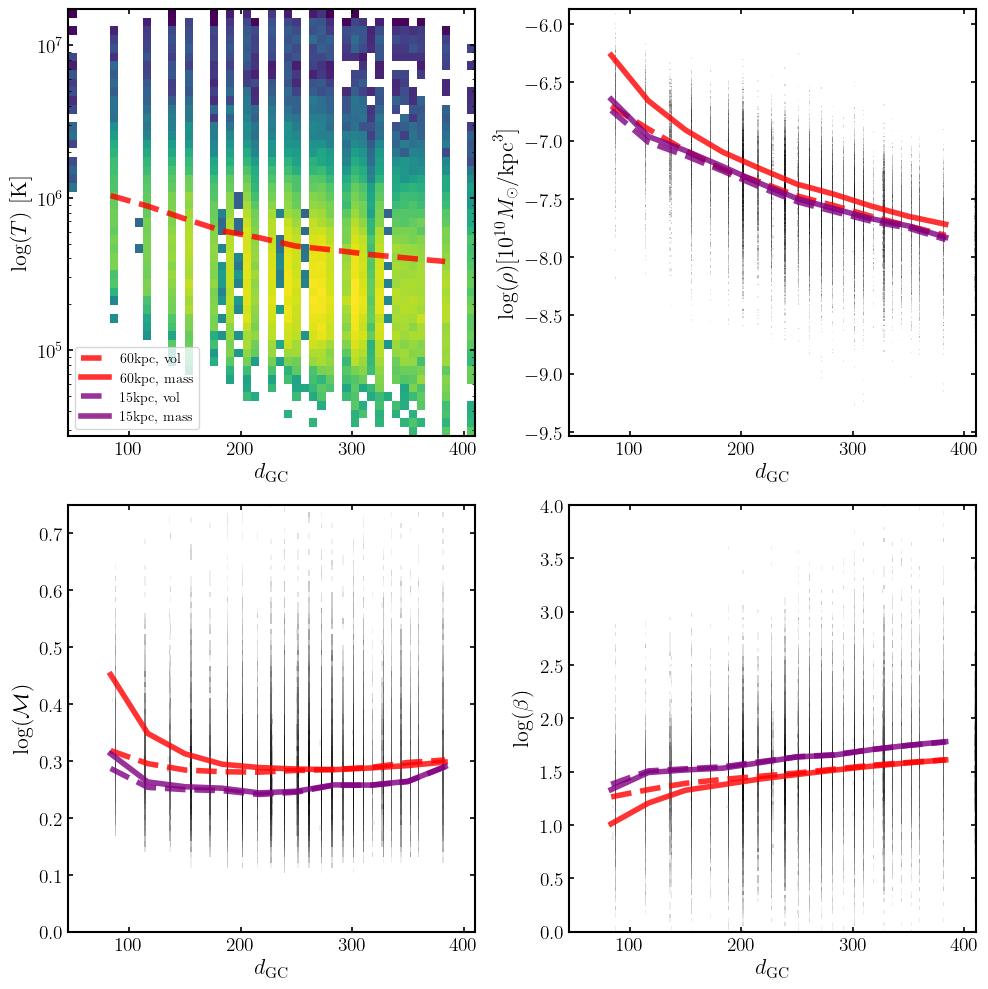

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

ax = axs[0, 0]
value = "TemperatureMean"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
hist_bins = [np.linspace(X.min(), X.max(), 50), np.logspace(np.log10(Y.min()), np.log10(Y.max()), 50)] # np.logspace(np.log10(X.min()), np.log10(X.max()), 50)
ax.hist2d(X, Y, bins=hist_bins, cmap="viridis", norm="log", density=True)
total_bins = 10
bins = np.linspace(100, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_m"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_v"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_m"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="15kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="15kpc, mass")
ax.set_ylabel(r"$\log(T)$ [K]")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.legend(loc="lower left")
ax.set_yscale("log")


ax = axs[0, 1]
value = "DensityMean"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_v"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(100, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_m"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_v"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_m"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\log(\rho)[10^{10}M_\odot/\mathrm{kpc}^3]$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")


ax = axs[1, 0]
value = "Mach"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_v_turb"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(100, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_m_turb"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_v_turb"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_m_turb"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\log(\mathcal{M})$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.set_ylim(0, 0.75)
# ax.set_yscale("log")


ax = axs[1, 1]
value = "betaMean"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_v"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(100, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = np.log10(table_coarse[f"{value}_m"][table_coarse["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_v"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = np.log10(table_fine[f"{value}_m"][table_fine["SFR"] == 0])
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="15kpc, mass")
ax.set_ylabel(r"$\log(\beta)$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.set_ylim(0, 4)
fig.tight_layout()
# fig.savefig("initial-conditions-vs-dist.pdf")

/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


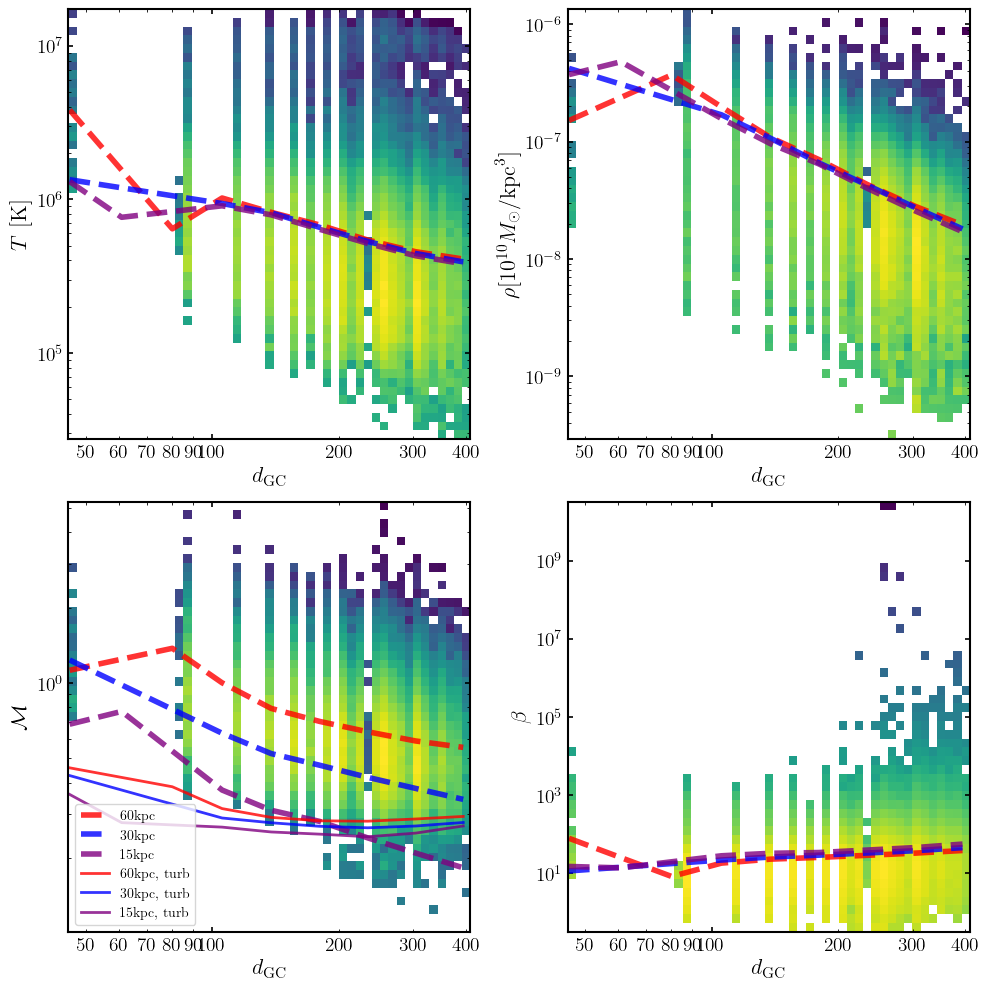

In [60]:
import matplotlib.ticker as mticker

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

values = [["TemperatureMean_v", "DensityMean_v"], ["Mach_v", "betaMean_v"]]
ylabels = [[r"$T$ [K]", r"$\rho [10^{10}M_\odot/\mathrm{kpc}^3]$"], [r"$\mathcal{M}$", r"$\beta$"]]
for i in range(2):
    for j in range(2):
        value = values[i][j]
        ax = axs[i, j]
        X = table_coarse["distGC"][table_coarse["SFR"] == 0]
        Y = table_coarse[f"{value}"][table_coarse["SFR"] == 0]
        mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
        X = X[mask]
        Y = Y[mask]
        hist_bins = [np.logspace(np.log10(X.min()), np.log10(X.max()), 50), np.logspace(np.log10(Y.min()), np.log10(Y.max()), 50)]
        ax.hist2d(X, Y, bins=hist_bins, cmap="viridis", norm="log", density=True)
        total_bins = 10
        bins = np.logspace(np.log10(40), np.log10(400), total_bins)
        delta = bins[1]-bins[0]
        idx  = np.digitize(X,bins)
        running_median_coarse_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])
        X = table_middle["distGC"][table_middle["SFR"] == 0]
        Y = table_middle[f"{value}"][table_middle["SFR"] == 0]
        mask = ~np.isnan(X) & ~np.isnan(Y)
        X = X[mask]
        Y = Y[mask]
        idx  = np.digitize(X,bins)
        running_median_middle_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])


        X = table_fine["distGC"][table_fine["SFR"] == 0]
        Y = table_fine[f"{value}"][table_fine["SFR"] == 0]
        mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
        X = X[mask]
        Y = Y[mask]
        idx = np.digitize(X,bins)
        running_median_fine_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])

        binx = np.array(bins-delta/2)
        ax.plot(binx[~np.isnan(running_median_coarse_v)], running_median_coarse_v[~np.isnan(running_median_coarse_v)],'r--',lw=4,alpha=.8, label="60kpc")
        ax.plot(binx[~np.isnan(running_median_middle_v)], running_median_middle_v[~np.isnan(running_median_middle_v)],'b--',lw=4,alpha=.8, label="30kpc")
        ax.plot(binx[~np.isnan(running_median_fine_v)], running_median_fine_v[~np.isnan(running_median_fine_v)],color="purple", linestyle='--',lw=4,alpha=.8, label="15kpc")
        ax.set_ylabel(ylabels[i][j])
        ax.set_xlabel(r"$d_{\mathrm{GC}}$")
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.xaxis.set_minor_formatter(mticker.ScalarFormatter())
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())


ax = axs[1, 0]
value = "Mach_v_turb"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
total_bins = 10
bins = np.logspace(np.log10(40), np.log10(400), total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])
X = table_middle["distGC"][table_middle["SFR"] == 0]
Y = table_middle[f"{value}"][table_middle["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_middle_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])

binx = np.array(bins-delta/2)
ax.plot(binx[~np.isnan(running_median_coarse_v)], running_median_coarse_v[~np.isnan(running_median_coarse_v)],'r-',lw=2,alpha=.8, label="60kpc, turb")
ax.plot(binx[~np.isnan(running_median_middle_v)], running_median_middle_v[~np.isnan(running_median_middle_v)],'b-',lw=2,alpha=.8, label="30kpc, turb")
ax.plot(binx[~np.isnan(running_median_fine_v)], running_median_fine_v[~np.isnan(running_median_fine_v)],color="purple", linestyle='-',lw=2,alpha=.8, label="15kpc, turb")

axs[1, 0].legend(loc="lower left")
fig.tight_layout()
fig.savefig("initial-conditions-vs-dist_new.pdf")

/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/u/jbiba/conda-envs/conda-env/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


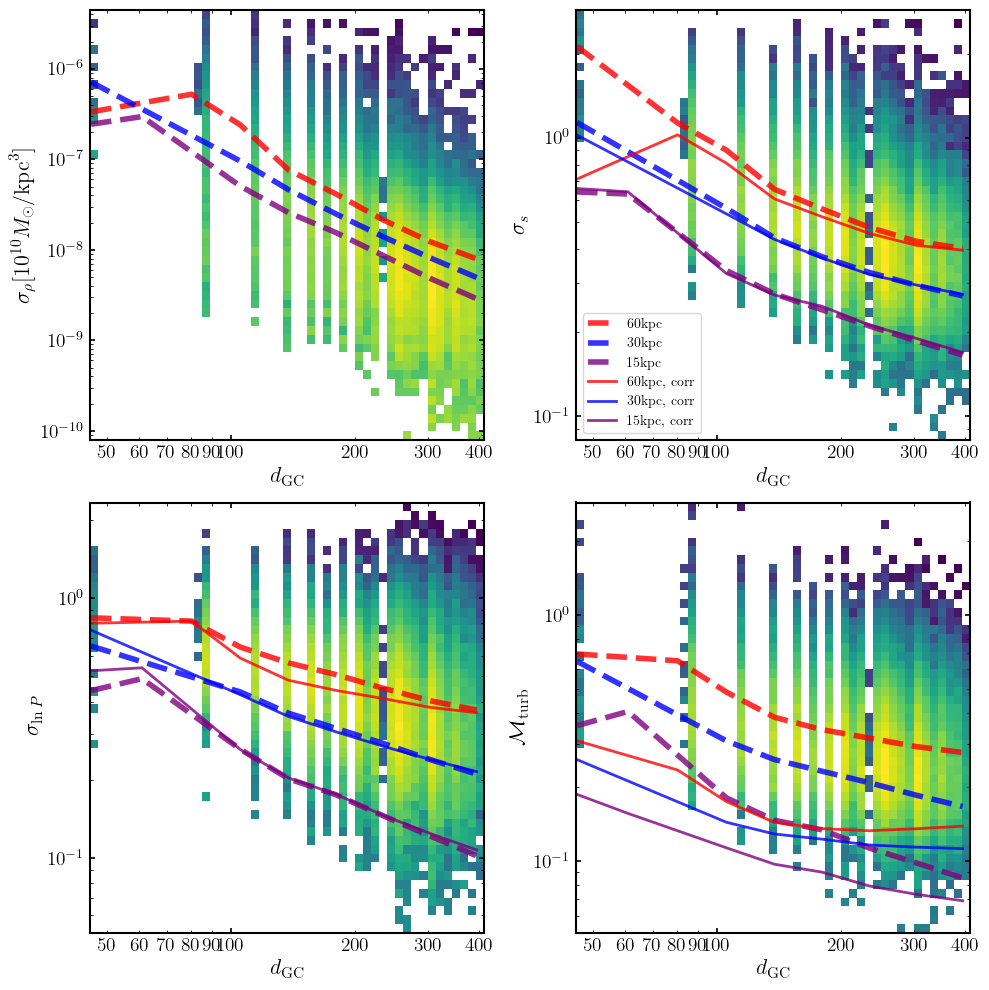

In [62]:
import matplotlib.ticker as mticker

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

values = [["DensityDisp_v", "LogDensityDisp_m"], ["LogPressureDisp_m", "CompressiveMach_v"]]

also_values = [[None, "LogDensityDispRadial_m"], ["LogPressureDispRadial_m", "CompressiveMach_v_turb"]]

ylabels = [[r"$\sigma_{\rho} [10^{10}M_\odot/\mathrm{kpc}^3]$", r"$\sigma_{s}$"], [r"$\sigma_{\ln P}$", r"$\mathcal{M}_{\mathrm{turb}}$"]]
for i in range(2):
    for j in range(2):
        value = values[i][j]
        ax = axs[i, j]
        X = table_coarse["distGC"][table_coarse["SFR"] == 0]
        Y = table_coarse[f"{value}"][table_coarse["SFR"] == 0]
        mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
        X = X[mask]
        Y = Y[mask]
        hist_bins = [np.logspace(np.log10(X.min()), np.log10(X.max()), 50), np.logspace(np.log10(Y.min()), np.log10(Y.max()), 50)]
        ax.hist2d(X, Y, bins=hist_bins, cmap="viridis", norm="log", density=True)
        total_bins = 10
        bins = np.logspace(np.log10(40), np.log10(400), total_bins)
        delta = bins[1]-bins[0]
        idx  = np.digitize(X,bins)
        running_median_coarse_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])
        X = table_middle["distGC"][table_middle["SFR"] == 0]
        Y = table_middle[f"{value}"][table_middle["SFR"] == 0]
        mask = ~np.isnan(X) & ~np.isnan(Y)
        X = X[mask]
        Y = Y[mask]
        idx  = np.digitize(X,bins)
        running_median_middle_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])


        X = table_fine["distGC"][table_fine["SFR"] == 0]
        Y = table_fine[f"{value}"][table_fine["SFR"] == 0]
        mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
        X = X[mask]
        Y = Y[mask]
        idx = np.digitize(X,bins)
        running_median_fine_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])

        binx = np.array(bins-delta/2)
        ax.plot(binx[~np.isnan(running_median_coarse_v)], running_median_coarse_v[~np.isnan(running_median_coarse_v)],'r--',lw=4,alpha=.8, label="60kpc")
        ax.plot(binx[~np.isnan(running_median_middle_v)], running_median_middle_v[~np.isnan(running_median_middle_v)],'b--',lw=4,alpha=.8, label="30kpc")
        ax.plot(binx[~np.isnan(running_median_fine_v)], running_median_fine_v[~np.isnan(running_median_fine_v)],color="purple", linestyle='--',lw=4,alpha=.8, label="15kpc")

        if also_values[i][j] is not None:
            value = also_values[i][j]
            X = table_coarse["distGC"][table_coarse["SFR"] == 0]
            Y = table_coarse[f"{value}"][table_coarse["SFR"] == 0]
            mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
            X = X[mask]
            Y = Y[mask]
            hist_bins = [np.logspace(np.log10(X.min()), np.log10(X.max()), 50), np.logspace(np.log10(Y.min()), np.log10(Y.max()), 50)]
            total_bins = 10
            bins = np.logspace(np.log10(40), np.log10(400), total_bins)
            delta = bins[1]-bins[0]
            idx  = np.digitize(X,bins)
            running_median_coarse_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])
            X = table_middle["distGC"][table_middle["SFR"] == 0]
            Y = table_middle[f"{value}"][table_middle["SFR"] == 0]
            mask = ~np.isnan(X) & ~np.isnan(Y)
            X = X[mask]
            Y = Y[mask]
            idx  = np.digitize(X,bins)
            running_median_middle_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])


            X = table_fine["distGC"][table_fine["SFR"] == 0]
            Y = table_fine[f"{value}"][table_fine["SFR"] == 0]
            mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
            X = X[mask]
            Y = Y[mask]
            idx = np.digitize(X,bins)
            running_median_fine_v = np.array([np.median(Y[idx==k]) for k in range(total_bins)])

            binx = np.array(bins-delta/2)
            ax.plot(binx[~np.isnan(running_median_coarse_v)], running_median_coarse_v[~np.isnan(running_median_coarse_v)],'r-',lw=2,alpha=.8, label="60kpc, corr")
            ax.plot(binx[~np.isnan(running_median_middle_v)], running_median_middle_v[~np.isnan(running_median_middle_v)],'b-',lw=2,alpha=.8, label="30kpc, corr")
            ax.plot(binx[~np.isnan(running_median_fine_v)], running_median_fine_v[~np.isnan(running_median_fine_v)],color="purple", linestyle='-',lw=2,alpha=.8, label="15kpc, corr")

        ax.set_ylabel(ylabels[i][j])
        ax.set_xlabel(r"$d_{\mathrm{GC}}$")
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.xaxis.set_minor_formatter(mticker.ScalarFormatter())
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

axs[0, 1].legend(loc="lower left")
fig.tight_layout()
fig.savefig("dispersions-vs-dist_new.pdf")

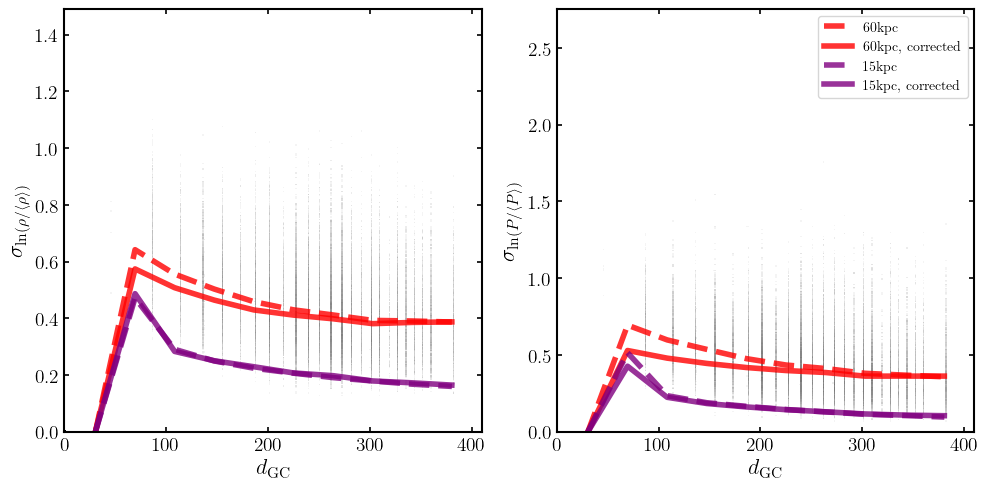

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
value = "LogDensityDisp"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}Radial_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}Radial_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc, vol")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, mass")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="30kpc, vol")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="30kpc, mass")
ax.set_ylabel(r"$\sigma_{\ln(\rho/\langle\rho\rangle)}$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")


ax = axs[1]
value = "LogPressureDisp"
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=300, cmap="Greys", norm="log", density=True)
total_bins = 10
bins = np.linspace(50, 400, total_bins)
delta = bins[1]-bins[0]
idx  = np.digitize(X,bins)
running_median_coarse_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_coarse["distGC"][table_coarse["SFR"] == 0]
Y = table_coarse[f"{value}Radial_v"][table_coarse["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx  = np.digitize(X,bins)
running_median_coarse_m = [np.median(Y[idx==k]) for k in range(total_bins)]


X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_v = [np.median(Y[idx==k]) for k in range(total_bins)]
X = table_fine["distGC"][table_fine["SFR"] == 0]
Y = table_fine[f"{value}Radial_v"][table_fine["SFR"] == 0]
mask = ~np.isnan(X) & ~np.isnan(Y) & ~np.isinf(X) & ~np.isinf(Y)
X = X[mask]
Y = Y[mask]
idx = np.digitize(X,bins)
running_median_fine_m = [np.median(Y[idx==k]) for k in range(total_bins)]

ax.plot(bins-delta/2, running_median_coarse_v,'r--',lw=4,alpha=.8, label="60kpc")
ax.plot(bins-delta/2, running_median_coarse_m,'r-',lw=4,alpha=.8, label="60kpc, corrected")
ax.plot(bins-delta/2, running_median_fine_v,color="purple", linestyle='--',lw=4,alpha=.8, label="15kpc")
ax.plot(bins-delta/2, running_median_fine_m,linestyle='-',color="purple",lw=4,alpha=.8, label="15kpc, corrected")
ax.set_ylabel(r"$\sigma_{\ln(P/\langle P \rangle)}$")
ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.legend()
fig.tight_layout()
fig.savefig("dispersions.pdf")

TemperatureMean 1010553.0 279816.9625 4224108.999999998
TemperatureMean 543003.0625 139602.903125 2125499.0
TemperatureMean 358632.8125 74428.031640625 1729841.6937499994
DensityMean 1.813899785929607e-07 1.6276121428404623e-08 1.088967246687389e-06
DensityMean 4.397539399292327e-08 7.509605559619105e-09 1.6992304665564004e-07
DensityMean 1.365602653180531e-08 2.510940799727024e-09 5.648160392723866e-08
Mach 0.28684571385383606 0.1429906189441681 0.6443019747734069
Mach 0.24372902512550354 0.11506455391645432 0.5184870719909666
Mach 0.2899923324584961 0.12304698079824447 0.70812449157238
betaMean 22.84347915649414 2.225286078453064 147.72232360839837
betaMean 34.663827896118164 3.4411683201789858 203.70168304443357
betaMean 43.44371795654297 4.177220344543457 275.8232116699219


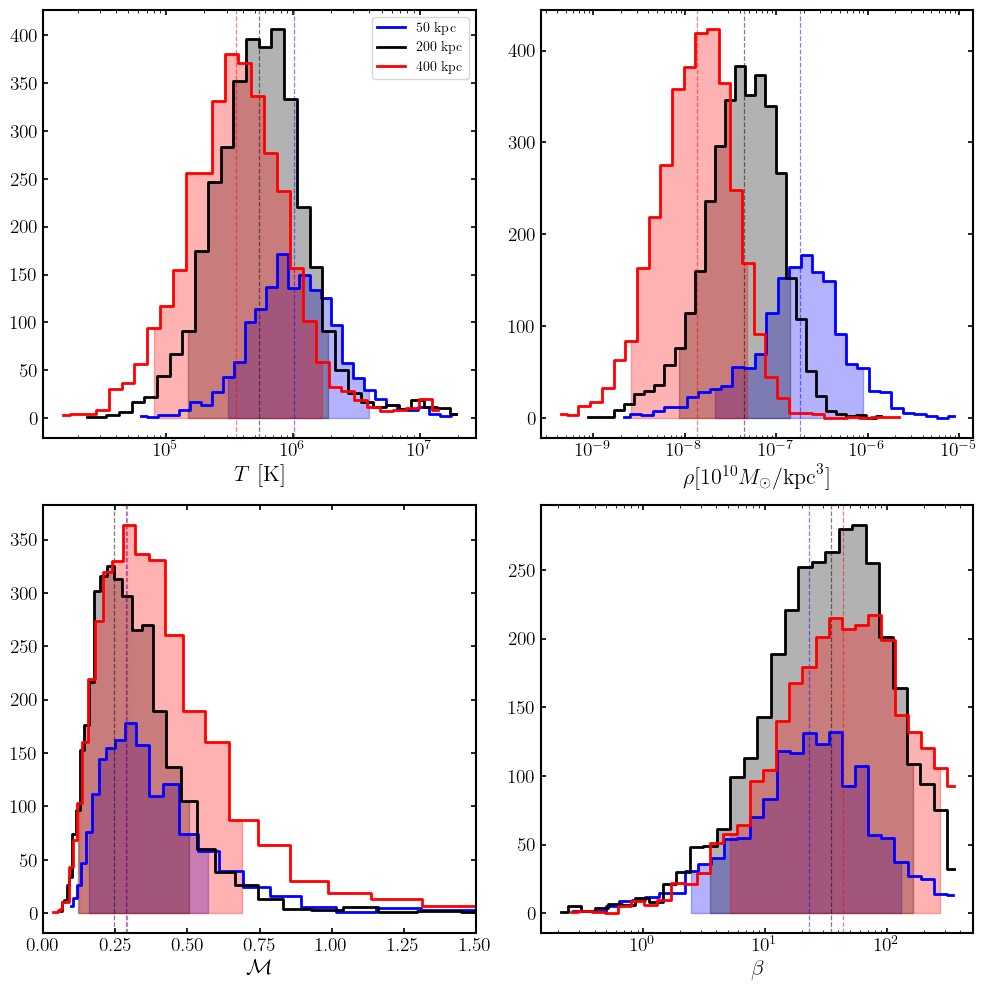

In [70]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

turb_dists = [50, 200, 400]
colors = list(reversed(['red', 'black', 'blue']))
bins = 30
windows = [50, 10, 20]

table = table_fine

ax = axs[0, 0]
value = "TemperatureMean"
for i, turb_dist in enumerate(turb_dists):
    Y = table[f"{value}_v"][(table["SFR"] == 0) & (table["distGC"] > turb_dist - windows[i]) & (table["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    med = np.median(Y)
    ax.axvline(med, color=colors[i], linestyle="--", alpha=0.5, linewidth=0.9)
    log_bins = np.logspace(np.log10(Y.min()), np.log10(Y.max()), bins + 1)
    counts, bin_edges = np.histogram(Y, bins=log_bins)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    p5, p95 = np.percentile(Y, [5, 95])
    ax.step(bin_centers, counts, where='mid', label=f'{turb_dist} kpc', color=colors[i])
    mask = (bin_centers >= p5) & (bin_centers <= p95)
    ax.fill_between(bin_centers[mask], 0, counts[mask], step='mid',
                    color=colors[i], alpha=0.3)
    print(value, med, p5, p95)


# ax.hist(Y, bins=100, histtype="step")
ax.set_xlabel(r"$T$ [K]")
ax.legend()
# ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.set_xscale("log")

ax = axs[0, 1]
value = "DensityMean"
for i, turb_dist in enumerate(turb_dists):
    Y = table[f"{value}_v"][(table["SFR"] == 0) & (table["distGC"] > turb_dist - windows[i]) & (table["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    med = np.median(Y)
    ax.axvline(med, color=colors[i], linestyle="--", alpha=0.5, linewidth=0.9)
    log_bins = np.logspace(np.log10(Y.min()), np.log10(Y.max()), bins + 1)
    counts, bin_edges = np.histogram(Y, bins=log_bins)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    p5, p95 = np.percentile(Y, [5, 95])
    ax.step(bin_centers, counts, where='mid', label=f'{turb_dist} kpc', color=colors[i])
    mask = (bin_centers >= p5) & (bin_centers <= p95)
    ax.fill_between(bin_centers[mask], 0, counts[mask], step='mid',
                    color=colors[i], alpha=0.3)
    print(value, med, p5, p95)

# ax.hist(Y, bins=100, histtype="step")
ax.set_xlabel(r"$\rho [10^{10}M_\odot/\mathrm{kpc}^3]$")
# ax.set_xlabel(r"$d_{\mathrm{GC}}$")
ax.set_xscale("log")


ax = axs[1, 0]
value = "Mach"
for i, turb_dist in enumerate(turb_dists):
    Y = table[f"{value}_v_turb"][(table["SFR"] == 0) & (table["distGC"] > turb_dist - windows[i]) & (table["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y) & (0 < Y)]
    med = np.median(Y)
    ax.axvline(med, color=colors[i], linestyle="--", alpha=0.5, linewidth=0.9)
    log_bins = np.logspace(np.log10(Y.min()), np.log10(Y.max()), bins + 1)
    counts, bin_edges = np.histogram(Y, bins=log_bins)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    p5, p95 = np.percentile(Y, [5, 95])
    ax.step(bin_centers, counts, where='mid', label=f'{turb_dist} kpc', color=colors[i])
    mask = (bin_centers >= p5) & (bin_centers <= p95)
    ax.fill_between(bin_centers[mask], 0, counts[mask], step='mid',
                    color=colors[i], alpha=0.3)
    print(value, med, p5, p95)

# ax.hist(Y, bins=100, histtype="step")
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_xlim(0, 1.5)
# ax.set_ylabel(r"$d_{\mathrm{GC}}$")


ax = axs[1, 1]
value = "betaMean"
for i, turb_dist in enumerate(turb_dists):
    Y = table[f"{value}_v"][(table["SFR"] == 0) & (table["distGC"] > turb_dist - windows[i]) & (table["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y) & (Y < 400)]
    med = np.median(Y)
    ax.axvline(med, color=colors[i], linestyle="--", alpha=0.5, linewidth=0.9)
    log_bins = np.logspace(np.log10(Y.min()), np.log10(Y.max()), bins + 1)
    counts, bin_edges = np.histogram(Y, bins=log_bins)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    p5, p95 = np.percentile(Y, [5, 95])
    ax.step(bin_centers, counts, where='mid', label=f'{turb_dist} kpc', color=colors[i])
    mask = (bin_centers >= p5) & (bin_centers <= p95)
    ax.fill_between(bin_centers[mask], 0, counts[mask], step='mid',
                    color=colors[i], alpha=0.3)
    print(value, med, p5, p95)

# ax.hist(Y, bins=100, histtype="step")
ax.set_xlabel(r"$\beta$")
# ax.set_ylabel(r"$d_{\mathrm{GC}}$")
ax.set_xscale("log")
fig.tight_layout()
fig.savefig("initial-conditions-distributions.pdf")

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

ax = axs[0, 0]
X = table_coarse["Mach_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]
Y = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.legend()
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, vol")

ax = axs[0, 1]
X = table_coarse["Mach_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]
Y = table_coarse["LogPressureDisp_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, mass")


ax = axs[1, 0]
X = table_fine["Mach_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 0.6) & (table_fine["LogPressureDisp_v"] < 0.2)]
Y = table_fine["LogPressureDisp_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 0.6) & (table_fine["LogPressureDisp_v"] < 0.2)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, vol")

ax = axs[1, 1]
X = table_fine["Mach_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 0.6) & (table_fine["LogPressureDisp_m"] < 0.2)]
Y = table_fine["LogPressureDisp_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 0.6) & (table_fine["LogPressureDisp_m"] < 0.2)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, mass")
fig.tight_layout()
fig.savefig("cutouts-pressmach-corrected.png")

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# do it with the compressible mach numbers
ax = axs[0, 0]
X = table_coarse["Mach_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]
Y = table_coarse["LogPressureDisp_v"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_v"] < 1) & (table_coarse["LogPressureDisp_v"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.legend()
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, vol")

ax = axs[0, 1]
X = table_coarse["Mach_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]
Y = table_coarse["LogPressureDisp_m"][(table_coarse["SFR"] == 0) & (table_coarse["Mach_m"] < 1) & (table_coarse["LogPressureDisp_m"] < 0.4)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("60kpc, mass")


ax = axs[1, 0]
X = table_fine["Mach_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 0.6) & (table_fine["LogPressureDisp_v"] < 0.2)]
Y = table_fine["LogPressureDisp_v"][(table_fine["SFR"] == 0) & (table_fine["Mach_v"] < 0.6) & (table_fine["LogPressureDisp_v"] < 0.2)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)))
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, vol")

ax = axs[1, 1]
X = table_fine["Mach_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 0.6) & (table_fine["LogPressureDisp_m"] < 0.2)]
Y = table_fine["LogPressureDisp_m"][(table_fine["SFR"] == 0) & (table_fine["Mach_m"] < 0.6) & (table_fine["LogPressureDisp_m"] < 0.2)]**2 * np.log(10)**2
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
ax.hist2d(X, Y, bins=500, cmap="plasma")
b_vals = np.linspace(1/3, 1, 5)
machs = np.linspace(0, 1, 1000)
black_to_red = LinearSegmentedColormap.from_list("black_white", ["black", "white"])
for i, b in enumerate(b_vals):
    ax.plot(machs, np.log(1 + b**2 * (5/3)**2 * machs**4), alpha=0.9, color=black_to_red(i/(5 - 1)), label=f"b = {b:.2f}")
ax.set_xlabel(r"$\mathcal{M}$")
ax.set_ylabel(r"$\sigma_s^2$")
ax.set_title("30kpc, mass")
fig.tight_layout()
fig.savefig("cutouts-pressmach.png")

In [ ]:
# calculate b values and do histograms for the distances

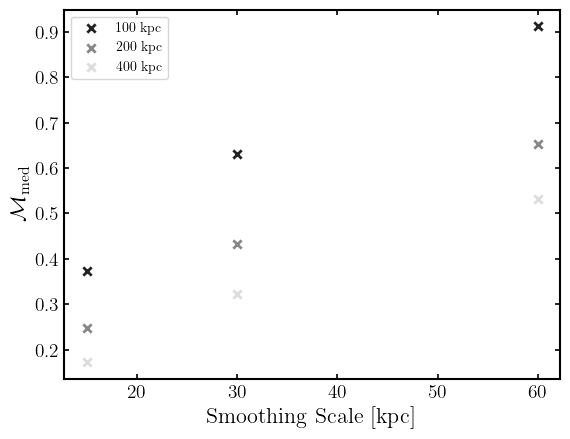

In [37]:
fig, ax = plt.subplots()
turb_dists = [100, 200, 400]
colors = list(reversed(['#dddddd', '#888888', '#222222']))
bins = 30
windows = [20, 10, 20]

value = "Mach"
for i, turb_dist in enumerate(turb_dists):
    Y = table_coarse[f"{value}_v"][(table_coarse["SFR"] == 0) & (table_coarse["distGC"] > turb_dist - windows[i]) & (table_coarse["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    medY = np.median(Y)
    ax.scatter([60], [medY], color=colors[i], label=f'{turb_dist} kpc', marker="x")

for i, turb_dist in enumerate(turb_dists):
    Y = table_middle[f"{value}_v"][(table_middle["SFR"] == 0) & (table_middle["distGC"] > turb_dist - windows[i]) & (table_middle["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    medY = np.median(Y)
    ax.scatter([30], [medY], color=colors[i], marker="x")

for i, turb_dist in enumerate(turb_dists):
    Y = table_fine[f"{value}_v"][(table_fine["SFR"] == 0) & (table_fine["distGC"] > turb_dist - windows[i]) & (table_fine["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    medY = np.median(Y)
    ax.scatter([15], [medY], color=colors[i], marker="x")

ax.legend()
ax.set_ylabel(r"$\mathcal{M}_{\mathrm{med}}$")
ax.set_xlabel(r"Smoothing Scale [kpc]")
fig.savefig("machnumber_scaling.pdf")

0.060992491971227386 0.12415792497926198 0.380456234397778
0.036374809884273086 0.08167471359215955 0.18378148268556302
0.02056336728786836 0.06791642400213957 0.17054535507020688


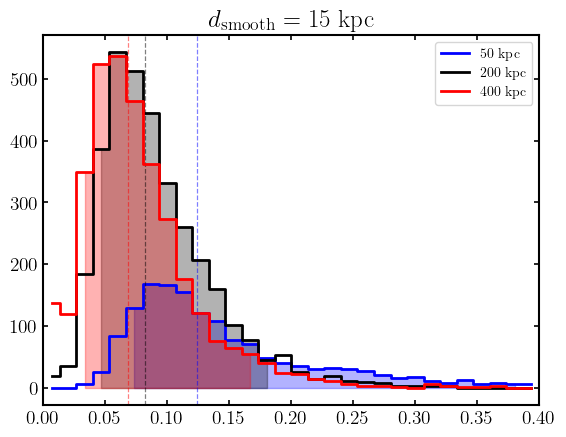

In [82]:
value = "CompressiveMach_v_turb"
turb_dists = [50, 200, 400]
colors = list(reversed(['red', 'black', 'blue']))
bins = 30
windows = [50, 10, 20]

fig, ax = plt.subplots()
for i, turb_dist in enumerate(turb_dists):
    Y = table_fine[f"{value}"][(table_fine["SFR"] == 0) & (table_fine["distGC"] > turb_dist - windows[i]) & (table_fine["distGC"] < turb_dist + windows[i])]
    Y = Y[~np.isnan(Y) & ~np.isinf(Y)]
    med = np.median(Y)
    ax.axvline(med, color=colors[i], linestyle="--", alpha=0.5, linewidth=0.9)
    log_bins = np.linspace(Y.min(), 0.4, bins + 1)
    counts, bin_edges = np.histogram(Y, bins=log_bins)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    p5, p95 = np.percentile(Y, [5, 95])
    ax.step(bin_centers, counts, where='mid', label=f'{turb_dist} kpc', color=colors[i])
    mask = (bin_centers >= p5) & (bin_centers <= p95)
    ax.fill_between(bin_centers[mask], 0, counts[mask], step='mid',
                    color=colors[i], alpha=0.3)
    print(p5, med, p95)
ax.set_xlim(0, 0.4)
ax.legend()
ax.set_title(r"$d_{\mathrm{smooth}} = $ 15 kpc")
fig.savefig("compressive_turb_machnumber-dist.pdf")

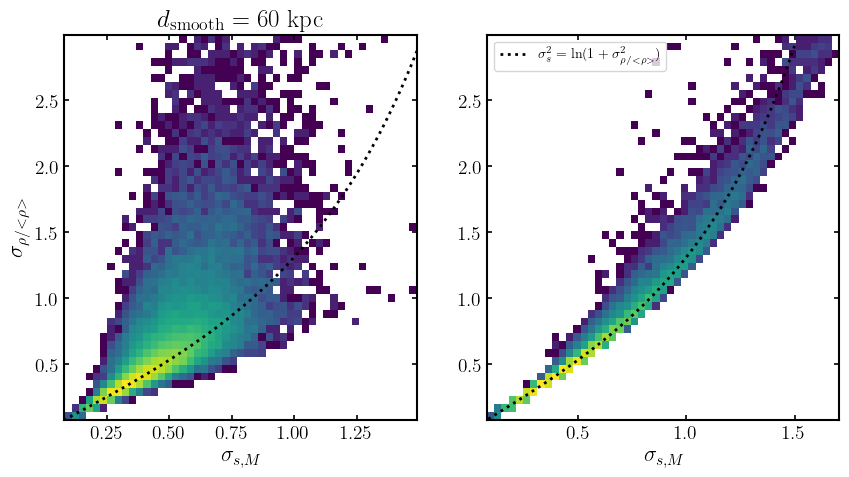

In [85]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
Y = (table_coarse["DensityDisp_v"]/table_coarse["DensityMean_v"])[(table_coarse["SFR"] == 0)]
X = table_coarse["LogDensityDisp_v"][(table_coarse["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 3)], Y[(X < 2) & (Y < 3)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.linspace(min(X), max(X), 50)
y_bins = np.linspace(min(Y), max(Y), 50)
ax.hist2d(X, Y, bins=[x_bins, y_bins], cmap="viridis", norm="log")
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.plot(np.linspace(0, 1.5, 100), np.sqrt(np.exp(np.linspace(0, 1.5, 100)**2) - 1), color="black", linestyle="dotted")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"$\sigma_{s, M}$")
ax.set_ylabel(r"$\sigma_{\rho/<\rho>}$")

ax = axs[1]
Y = (table_coarse["DensityDisp_v"]/table_coarse["DensityMean_v"])[(table_coarse["SFR"] == 0)]
X = table_coarse["LogDensityDisp_m"][(table_coarse["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 3)], Y[(X < 2) & (Y < 3)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.linspace(min(X), max(X), 50)
y_bins = np.linspace(min(Y), max(Y), 50)
ax.hist2d(X, Y, bins=[x_bins, y_bins], cmap="viridis", norm="log")
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.plot(np.linspace(0, 1.5, 100), np.sqrt(np.exp(np.linspace(0, 1.5, 100)**2) - 1), color="black", linestyle="dotted", label=r"$\sigma_{s}^2 = \ln(1 + \sigma_{\rho/<\rho>}^2)$")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"$\sigma_{s, M}$")
ax.legend()
axs[0].set_title(r"$d_{\mathrm{smooth}} = $ 60 kpc")
fig.savefig("is-mass-weighted-better.pdf")

In [13]:
table_coarse.keys()

dict_keys(['CompressiveFraction', 'CompressiveFraction_turb', 'CompressiveMach_v', 'CompressiveMach_v_turb', 'DensityDisp_m', 'DensityDisp_v', 'DensityMean_m', 'DensityMean_v', 'LogDensityDispRadial_m', 'LogDensityDispRadial_v', 'LogDensityDisp_m', 'LogDensityDisp_v', 'LogPressureDispRadial_m', 'LogPressureDispRadial_v', 'LogPressureDisp_m', 'LogPressureDisp_v', 'Mach_m', 'Mach_m_turb', 'Mach_v', 'Mach_v_turb', 'MagneticFieldMean_m', 'MagneticFieldMean_v', 'MagneticPressMean_m', 'MagneticPressMean_v', 'MeanElectronAbundance_m', 'MeanElectronAbundance_v', 'MeanMolecularWeightMean_m', 'MeanMolecularWeightMean_v', 'PressureDisp _v', 'PressureDisp_m', 'PressureMean_m', 'PressureMean_v', 'SFR', 'SolenoidalFraction', 'SolenoidalFraction_turb', 'SoundspeedMean_m', 'SoundspeedMean_v', 'TemperatureMean_m', 'TemperatureMean_v', 'VelocityDisp_m', 'VelocityMean_m', 'VelocityMean_v', 'VeloctiyDisp_v', 'betaMean_m', 'betaMean_v', 'distBH', 'distGC', 'galactic_cos', 'subhaloId'])

[0.2459521  0.63847345 1.11099505 ... 0.20525312 0.39993274 0.34964693] [0.09926384 0.5050875  0.47507464 ... 0.22728707 0.25621845 0.36993403]


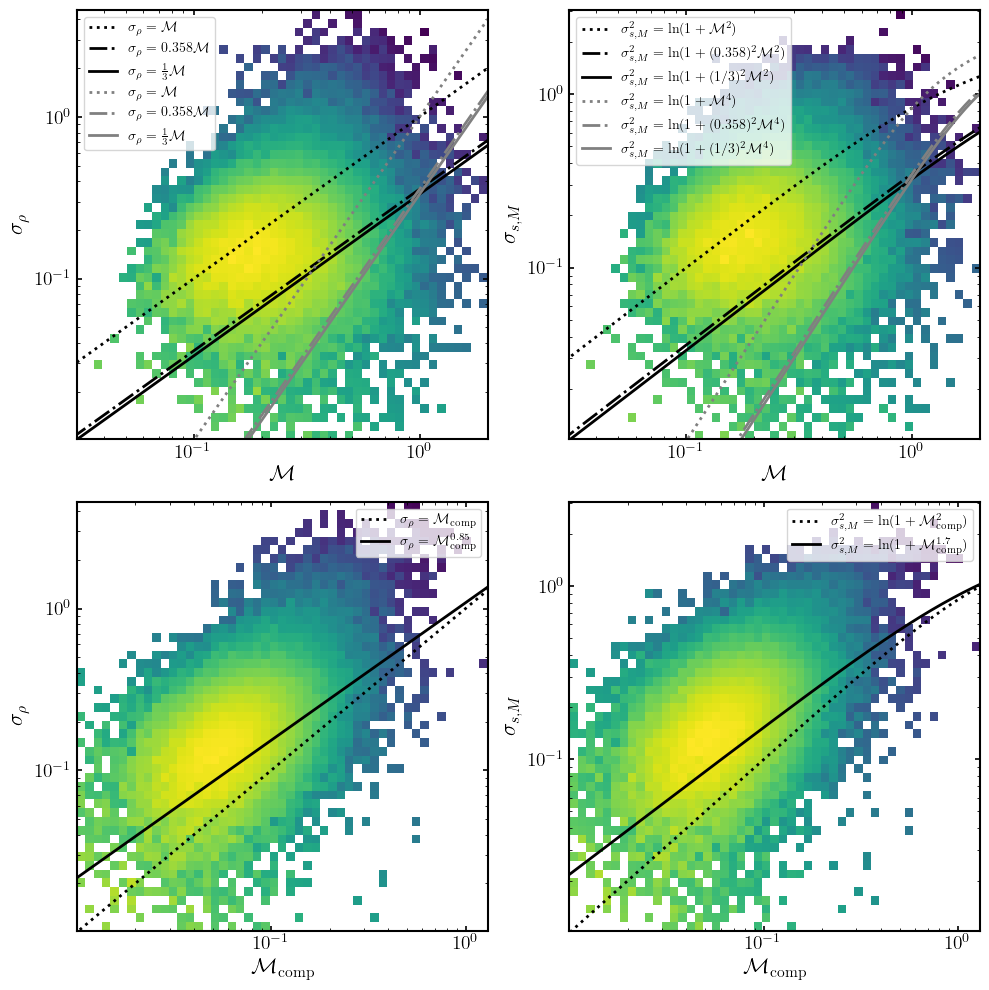

In [86]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

this_table = table_fine


Y = (this_table["DensityDisp_v"]/this_table["DensityMean_v"])[(this_table["SFR"] == 0)]
X = this_table["Mach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
print(X, Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[0, 0].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = (this_table["LogDensityDispRadial_m"])[(this_table["SFR"] == 0)]
X = this_table["Mach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[0, 1].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = (this_table["DensityDisp_v"]/this_table["DensityMean_v"])[(this_table["SFR"] == 0)]
X = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[1, 0].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = (this_table["LogDensityDispRadial_m"])[(this_table["SFR"] == 0)]
X = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[1, 1].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

axs[0, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[0, 0].set_xlabel(r"$\mathcal{M}$")
axs[0, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[0, 1].set_xlabel(r"$\mathcal{M}$")
axs[1, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[1, 0].set_xlabel(r"$\mathcal{M}_\mathrm{comp}$")
axs[1, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[1, 1].set_xlabel(r"$\mathcal{M}_\mathrm{comp}$")

axs[0, 0].set_xscale("log")
axs[0, 0].set_yscale("log")
axs[0, 1].set_xscale("log")
axs[0, 1].set_yscale("log")
axs[1, 1].set_xscale("log")
axs[1, 1].set_yscale("log")
axs[1, 0].set_xscale("log")
axs[1, 0].set_yscale("log")

xlim = axs[0, 0].get_xlim()
ylim = axs[0, 0].get_ylim()
axs[0, 0].plot(np.linspace(0, 10, 100), np.linspace(0, 10, 100), color="black", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.358*np.linspace(0, 10, 100), color="black", linestyle="dashdot", label=r"$\sigma_{\rho} = 0.358 \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.333*np.linspace(0, 10, 100), color="black", linestyle="-", label=r"$\sigma_{\rho} = \frac{1}{3}\mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), np.linspace(0, 10, 100)**2, color="grey", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.358*np.linspace(0, 10, 100)**2, color="grey", linestyle="dashdot", label=r"$\sigma_{\rho} = 0.358 \mathcal{M}$")
axs[0, 0].plot(np.linspace(0, 10, 100), 0.333*np.linspace(0, 10, 100)**2, color="grey", linestyle="-", label=r"$\sigma_{\rho} = \frac{1}{3}\mathcal{M}$")
axs[0, 0].set_xlim(xlim)
axs[0, 0].set_ylim(ylim)

xlim = axs[0, 1].get_xlim()
ylim = axs[0, 1].get_ylim()
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (1)**2 * np.linspace(0, 10, 100)**2)), color="black", linestyle="dotted", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}^2)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.358)**2 * np.linspace(0, 10, 100)**2)), color="black", linestyle="dashdot", label=r"$\sigma_{s, M}^2 = \ln(1 + (0.358)^2\mathcal{M}^2)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.3333)**2 * np.linspace(0, 10, 100)**2)), color="black", linestyle="-", label=r"$\sigma_{s, M}^2 = \ln(1 + (1/3)^2\mathcal{M}^2)$")

axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (1)**2 * np.linspace(0, 10, 100)**4)), color="grey", linestyle="dotted", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}^4)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.358)**2 * np.linspace(0, 10, 100)**4)), color="grey", linestyle="dashdot", label=r"$\sigma_{s, M}^2 = \ln(1 + (0.358)^2\mathcal{M}^4)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (0.3333)**2 * np.linspace(0, 10, 100)**4)), color="grey", linestyle="-", label=r"$\sigma_{s, M}^2 = \ln(1 + (1/3)^2\mathcal{M}^4)$")

axs[0, 1].set_xlim(xlim)
axs[0, 1].set_ylim(ylim)
axs[0, 1].legend()


xlim = axs[1, 0].get_xlim()
ylim = axs[1, 0].get_ylim()
axs[1, 0].plot(np.linspace(0, 10, 1000), np.linspace(0, 10, 1000)**(1), color="black", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}_{\mathrm{comp}}$")
axs[1, 0].plot(np.linspace(0, 10, 1000), 1.086 * np.linspace(0, 10, 1000)**(0.85), color="black", linestyle="-", label=r"$\sigma_{\rho} = \mathcal{M}_{\mathrm{comp}}^{0.85}$")
axs[1, 0].set_xlim(xlim)
axs[1, 0].set_ylim(ylim)
axs[1, 0].legend()

xlim = axs[1, 1].get_xlim()
ylim = axs[1, 1].get_ylim()
axs[1, 1].plot(np.linspace(0, 10, 1000), np.sqrt(np.log(1 + np.linspace(0, 10, 1000)**2)), color="black", linestyle="dotted", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}_{\mathrm{comp}}^2)$")
axs[1, 1].plot(np.linspace(0, 10, 1000), np.sqrt(np.log(1 + 1.086**2 * np.linspace(0, 10, 1000)**(1.7))), color="black", linestyle="-", label=r"$\sigma_{s, M}^2 = \ln(1 + \mathcal{M}_{\mathrm{comp}}^{1.7})$")
axs[1, 1].set_xlim(xlim)
axs[1, 1].set_ylim(ylim)
axs[1, 1].legend()

axs[0, 0].legend()
fig.tight_layout()
fig.savefig("densmach-relation_new.pdf")

[0.2459521  0.63847345 1.11099505 ... 0.20525312 0.39993274 0.34964693] [0.13521904 0.04840005 0.09142148 ... 0.24074651 0.36876159 0.45424494]


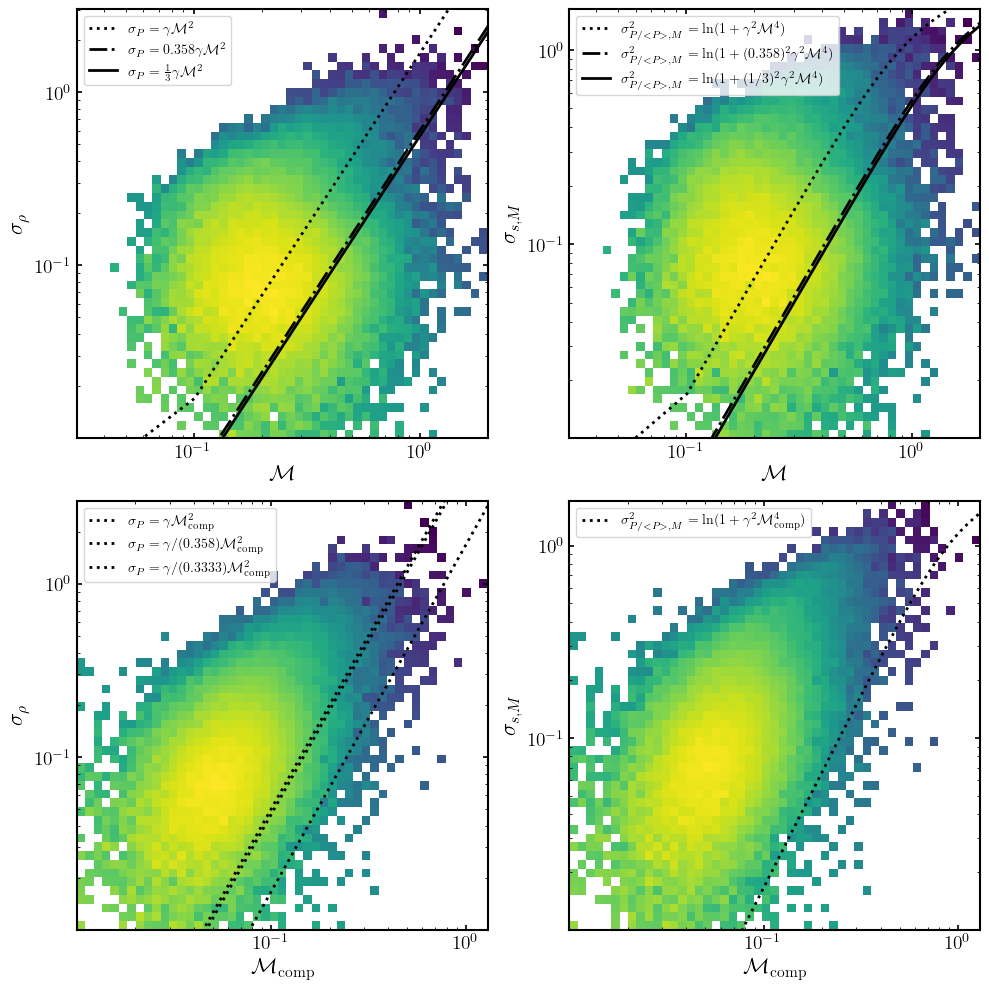

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

this_table = table_fine

Y = (this_table["PressureDisp _v"]/this_table["PressureMean_v"])[(this_table["SFR"] == 0)]
X = this_table["Mach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
print(X, Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[0, 0].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = (this_table["LogPressureDisp_m"])[(this_table["SFR"] == 0)]
X = this_table["Mach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[0, 1].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = (this_table["PressureDisp _v"]/this_table["PressureMean_v"])[(this_table["SFR"] == 0)]
X = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[1, 0].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = (this_table["LogPressureDisp_m"])[(this_table["SFR"] == 0)]
X = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
axs[1, 1].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

axs[0, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[0, 0].set_xlabel(r"$\mathcal{M}$")
axs[0, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[0, 1].set_xlabel(r"$\mathcal{M}$")
axs[1, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[1, 0].set_xlabel(r"$\mathcal{M}_\mathrm{comp}$")
axs[1, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[1, 1].set_xlabel(r"$\mathcal{M}_\mathrm{comp}$")

axs[0, 0].set_xscale("log")
axs[0, 0].set_yscale("log")
axs[0, 1].set_xscale("log")
axs[0, 1].set_yscale("log")
axs[1, 1].set_xscale("log")
axs[1, 1].set_yscale("log")
axs[1, 0].set_xscale("log")
axs[1, 0].set_yscale("log")

xlim = axs[0, 0].get_xlim()
ylim = axs[0, 0].get_ylim()
axs[0, 0].plot(np.linspace(0, 10, 100), 5/3 * np.linspace(0, 10, 100)**2, color="black", linestyle="dotted", label=r"$\sigma_{P} = \gamma \mathcal{M}^2$")
axs[0, 0].plot(np.linspace(0, 10, 100), 5/3 * 0.358*np.linspace(0, 10, 100)**2, color="black", linestyle="dashdot", label=r"$\sigma_{P} = 0.358 \gamma \mathcal{M}^2$")
axs[0, 0].plot(np.linspace(0, 10, 100), 5/3 * 0.333*np.linspace(0, 10, 100)**2, color="black", linestyle="-", label=r"$\sigma_{P} = \frac{1}{3} \gamma \mathcal{M}^2$")
axs[0, 0].set_xlim(xlim)
axs[0, 0].set_ylim(ylim)

xlim = axs[0, 1].get_xlim()
ylim = axs[0, 1].get_ylim()
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (5/3)**2 * (1)**2 * np.linspace(0, 10, 100)**4)), color="black", linestyle="dotted", label=r"$\sigma_{P/<P>, M}^2 = \ln(1 + \gamma^2 \mathcal{M}^4)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (5/3)**2 * (0.358)**2 * np.linspace(0, 10, 100)**4)), color="black", linestyle="dashdot", label=r"$\sigma_{P/<P>, M}^2 = \ln(1 + (0.358)^2 \gamma^2 \mathcal{M}^4)$")
axs[0, 1].plot(np.linspace(0, 10, 100), np.sqrt(np.log(1 + (5/3)**2 * (0.3333)**2 * np.linspace(0, 10, 100)**4)), color="black", linestyle="-", label=r"$\sigma_{P/<P>, M}^2 = \ln(1 + (1/3)^2 \gamma^2 \mathcal{M}^4)$")

axs[0, 1].set_xlim(xlim)
axs[0, 1].set_ylim(ylim)
axs[0, 1].legend()


xlim = axs[1, 0].get_xlim()
ylim = axs[1, 0].get_ylim()
axs[1, 0].plot(np.linspace(0, 10, 1000), 1/(1) * 5/3 * np.linspace(0, 10, 1000)**(2), color="black", linestyle="dotted", label=r"$\sigma_{P} = \gamma \mathcal{M}^2_{\mathrm{comp}}$")
axs[1, 0].plot(np.linspace(0, 10, 1000), 1/(0.358) * 5/3 * np.linspace(0, 10, 1000)**(2), color="black", linestyle="dotted", label=r"$\sigma_{P} = \gamma /(0.358)\mathcal{M}^2_{\mathrm{comp}}$")
axs[1, 0].plot(np.linspace(0, 10, 1000), 1/(0.3333) * 5/3 * np.linspace(0, 10, 1000)**(2), color="black", linestyle="dotted", label=r"$\sigma_{P} = \gamma/(0.3333) \mathcal{M}^2_{\mathrm{comp}}$")

axs[1, 0].set_xlim(xlim)
axs[1, 0].set_ylim(ylim)
axs[1, 0].legend()

xlim = axs[1, 1].get_xlim()
ylim = axs[1, 1].get_ylim()
axs[1, 1].plot(np.linspace(0, 10, 1000), np.sqrt(np.log(1 + (5/3)**2 * np.linspace(0, 10, 1000)**4)), color="black", linestyle="dotted", label=r"$\sigma_{P/<P>, M}^2 = \ln(1 + \gamma^2 \mathcal{M}_{\mathrm{comp}}^4)$")
axs[1, 1].set_xlim(xlim)
axs[1, 1].set_ylim(ylim)
axs[1, 1].legend()

axs[0, 0].legend()
fig.tight_layout()
fig.savefig("pressmach-relation-new.pdf")

0.42385330170760716 0.5476748203336047 0.7363251572466875
0.37261707597917715 0.48475030948806075 0.6454885924611768
0.32931652702123976 0.48379697760725265 0.6667842726373451


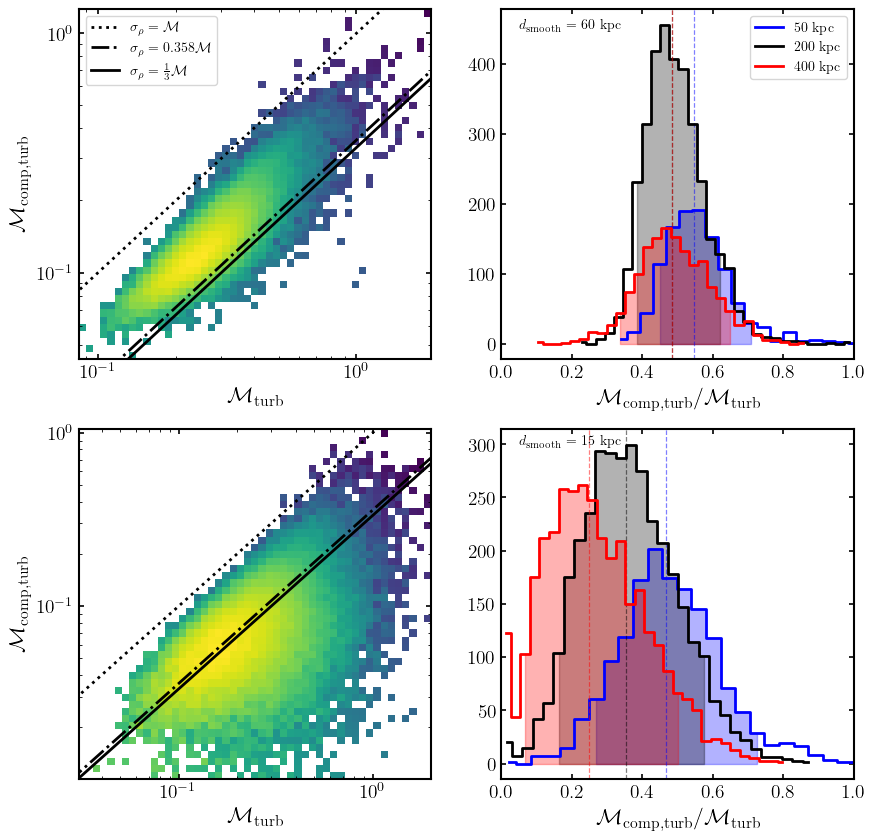

In [104]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
this_table = table_coarse

ax = axs[0, 0]
X = (this_table["Mach_v_turb"])[(this_table["SFR"] == 0)]
Y = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 2) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 2) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
ax.hist2d(X, Y, bins=[x_bins, y_bins], cmap="viridis", norm="log", density=True)
ax.set_yscale("log")
ax.set_xscale("log")

xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.plot(np.linspace(0, 10, 100), np.linspace(0, 10, 100), color="black", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}$")
ax.plot(np.linspace(0, 10, 100), 0.358*np.linspace(0, 10, 100), color="black", linestyle="dashdot", label=r"$\sigma_{\rho} = 0.358 \mathcal{M}$")
ax.plot(np.linspace(0, 10, 100), 0.333*np.linspace(0, 10, 100), color="black", linestyle="-", label=r"$\sigma_{\rho} = \frac{1}{3}\mathcal{M}$")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_ylabel(r"$\mathcal{M}_{\mathrm{comp, turb}}$")
ax.set_xlabel(r"$\mathcal{M}_{\mathrm{turb}}$")
ax.legend()

ax = axs[0, 1]
turb_dists = [50, 200, 400]
colors = list(reversed(['red', 'black', 'blue']))
bins = 30
windows = [50, 10, 20]
this_table = table_coarse
for i, turb_dist in enumerate(turb_dists):
    comp_mach = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0) & (this_table["distGC"] > turb_dist - windows[i]) & (this_table["distGC"] < turb_dist + windows[i])]
    mach = this_table["Mach_v_turb"][(this_table["SFR"] == 0) & (this_table["distGC"] > turb_dist - windows[i]) & (this_table["distGC"] < turb_dist + windows[i])]
    Y = comp_mach/mach
    Y = Y[~np.isnan(Y) & ~np.isinf(Y) & (Y > 0)]
    med = np.median(Y)
    ax.axvline(med, color=colors[i], linestyle="--", alpha=0.5, linewidth=0.9)
    log_bins = np.linspace(Y.min(), Y.max(), bins + 1)
    counts, bin_edges = np.histogram(Y, bins=log_bins)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    p5, p95 = np.percentile(Y, [5, 95])
    ax.step(bin_centers, counts, where='mid', label=f'{turb_dist} kpc', color=colors[i])
    mask = (bin_centers >= p5) & (bin_centers <= p95)
    ax.fill_between(bin_centers[mask], 0, counts[mask], step='mid',
                    color=colors[i], alpha=0.3)
    print(p5, med, p95)
ax.set_xlim(0, 1.0)
ax.legend()
ax.set_xlabel(r"$\mathcal{M}_{\mathrm{comp, turb}}/\mathcal{M}_{\mathrm{turb}}$")
ax.text(0.05, 450, r"$d_{\mathrm{smooth}} = $ 60 kpc")


this_table = table_fine

ax = axs[1, 0]
X = (this_table["Mach_v_turb"])[(this_table["SFR"] == 0)]
Y = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0)]
X, Y = X[(X < 2) & (Y < 2) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 2) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
ax.hist2d(X, Y, bins=[x_bins, y_bins], cmap="viridis", norm="log", density=True)
ax.set_yscale("log")
ax.set_xscale("log")

xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.plot(np.linspace(0, 10, 100), np.linspace(0, 10, 100), color="black", linestyle="dotted", label=r"$\sigma_{\rho} = \mathcal{M}$")
ax.plot(np.linspace(0, 10, 100), 0.358*np.linspace(0, 10, 100), color="black", linestyle="dashdot", label=r"$\sigma_{\rho} = 0.358 \mathcal{M}$")
ax.plot(np.linspace(0, 10, 100), 0.333*np.linspace(0, 10, 100), color="black", linestyle="-", label=r"$\sigma_{\rho} = \frac{1}{3}\mathcal{M}$")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_ylabel(r"$\mathcal{M}_{\mathrm{comp, turb}}$")
ax.set_xlabel(r"$\mathcal{M}_{\mathrm{turb}}$")

ax = axs[1, 1]
turb_dists = [50, 200, 400]
colors = list(reversed(['red', 'black', 'blue']))
bins = 30
windows = [50, 10, 20]
this_table = table_fine
for i, turb_dist in enumerate(turb_dists):
    comp_mach = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0) & (this_table["distGC"] > turb_dist - windows[i]) & (this_table["distGC"] < turb_dist + windows[i])]
    mach = this_table["Mach_v_turb"][(this_table["SFR"] == 0) & (this_table["distGC"] > turb_dist - windows[i]) & (this_table["distGC"] < turb_dist + windows[i])]
    Y = comp_mach/mach
    Y = Y[~np.isnan(Y) & ~np.isinf(Y) & (Y > 0)]
    med = np.median(Y)
    ax.axvline(med, color=colors[i], linestyle="--", alpha=0.5, linewidth=0.9)
    log_bins = np.linspace(Y.min(), Y.max(), bins + 1)
    counts, bin_edges = np.histogram(Y, bins=log_bins)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    p5, p95 = np.percentile(Y, [5, 95])
    ax.step(bin_centers, counts, where='mid', label=f'{turb_dist} kpc', color=colors[i])
    mask = (bin_centers >= p5) & (bin_centers <= p95)
    ax.fill_between(bin_centers[mask], 0, counts[mask], step='mid',
                    color=colors[i], alpha=0.3)
ax.set_xlim(0, 1.0)
ax.text(0.05, 300, r"$d_{\mathrm{smooth}} = $ 15 kpc")
ax.set_xlabel(r"$\mathcal{M}_{\mathrm{comp, turb}}/\mathcal{M}_{\mathrm{turb}}$")
fig.savefig("b_parameter_from_commach.pdf")

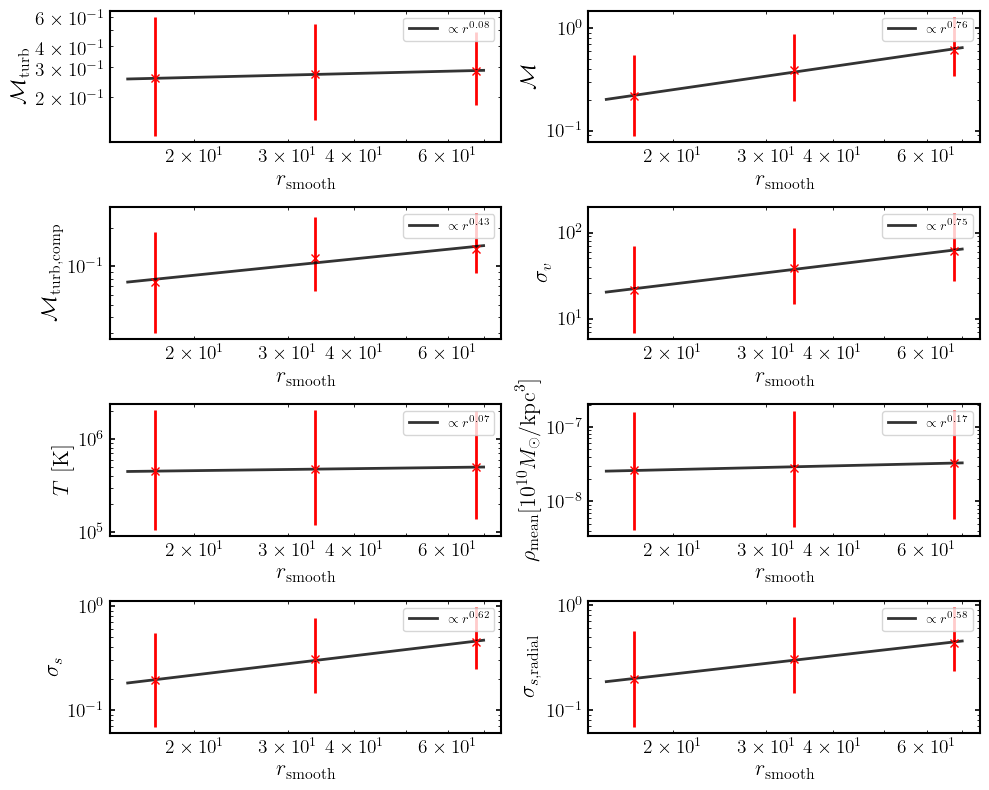

In [88]:
# structure functions
tables = [table_coarse, table_middle, table_fine]
smoothings = [541/(2**3), 541/(2**4), 541/(2**5)]

fig, axs = plt.subplots(4, 2, figsize=(10, 8))

values = [["Mach_v_turb", "Mach_v"],
          ["CompressiveMach_v_turb", "VeloctiyDisp_v"],
          ["TemperatureMean_v", "DensityMean_v"],
          ["LogDensityDisp_m", "LogDensityDispRadial_m"]]


ylabels = [[r"$\mathcal{M}_{\mathrm{turb}}$", r"$\mathcal{M}$"],
           [r"$\mathcal{M}_{\mathrm{turb, comp}}$", r"$\sigma_{v}$"],
           [r"$T$ [K]", r"$\rho_{\mathrm{mean}} [10^{10}M_\odot/\mathrm{kpc}^3]$"], 
           [r"$\sigma_s$", r"$\sigma_{s, \mathrm{radial}}$"]]

for i in range(2):
    for j in range(4):
        meds = list()
        for table, smoothing in zip(tables, smoothings):
            Y = table[f"{values[j][i]}"][(table["SFR"] == 0) & (table["distGC"] > 0) & (table["distGC"] < 500)]
            Y = Y[~np.isnan(Y) & ~np.isinf(Y) & (0 < Y)]
            med = np.median(Y)
            # err = np.std(Y)
            p5, p50, p95 = np.percentile(Y, [5, 50, 95])
            meds.append(med)
            axs[j, i].errorbar([smoothing], [med], yerr=[[med - p5], [p95 - med]], fmt="x", color="red")

        m, c = np.polyfit(np.log10(np.array(smoothings)), np.log10(np.array(meds)), 1)

        # xlim = axs[j, i].get_xlim()
        # ylim = axs[j, i].get_ylim()
        axs[j, i].plot(np.logspace(np.log10(15), np.log10(70), 100), 10**(c) * (np.logspace(np.log10(15), np.log10(70), 100))**(m), color="black", alpha=0.8, label=fr"$\propto r^{{{m:.2f}}}$")
        # # axs.plot(np.logspace(0.1, 100, 100), 0.07 * np.logspace(0.1, 100, 100)**(1/3))
        
        # axs[j, i].set_xlim(xlim)
        # axs[j, i].set_ylim(ylim)
        axs[j, i].legend()
        axs[j, i].set_yscale("log")
        axs[j, i].set_xscale("log")
        axs[j, i].set_xlabel(r"$r_{\mathrm{smooth}}$")
        axs[j, i].set_ylabel(ylabels[j][i])

        # if values[j][i] == "DensityMean_v":
        #     axs[j, i].set_ylim(1e-9, 2e-7)
fig.tight_layout()
fig.savefig("smoothing-scaling.pdf")

In [174]:
541/(2**5)

16.90625

In [109]:
table_coarse.keys()

dict_keys(['CompressiveFraction', 'CompressiveFraction_turb', 'CompressiveMach_v', 'CompressiveMach_v_turb', 'DensityDisp_m', 'DensityDisp_v', 'DensityMean_m', 'DensityMean_v', 'LogDensityDispRadial_m', 'LogDensityDispRadial_v', 'LogDensityDisp_m', 'LogDensityDisp_v', 'LogPressureDispRadial_m', 'LogPressureDispRadial_v', 'LogPressureDisp_m', 'LogPressureDisp_v', 'Mach_m', 'Mach_m_turb', 'Mach_v', 'Mach_v_turb', 'MagneticFieldMean_m', 'MagneticFieldMean_v', 'MagneticPressMean_m', 'MagneticPressMean_v', 'MeanElectronAbundance_m', 'MeanElectronAbundance_v', 'MeanMolecularWeightMean_m', 'MeanMolecularWeightMean_v', 'PressureDisp _v', 'PressureDisp_m', 'PressureMean_m', 'PressureMean_v', 'SFR', 'SolenoidalFraction', 'SolenoidalFraction_turb', 'SoundspeedMean_m', 'SoundspeedMean_v', 'TemperatureMean_m', 'TemperatureMean_v', 'VelocityDisp_m', 'VelocityMean_m', 'VelocityMean_v', 'VeloctiyDisp_v', 'betaMean_m', 'betaMean_v', 'distBH', 'distGC', 'galactic_cos', 'subhaloId'])

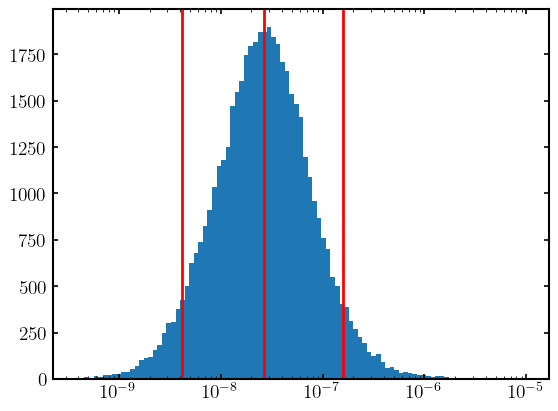

In [148]:
Y = table_fine["DensityMean_v"][(table_fine["SFR"] == 0) & (table["distGC"] > 0) & (table["distGC"] < 500)]
med = np.median(Y[~np.isnan(Y) & ~np.isinf(Y)])
p5, p50, p95 = np.percentile(Y[~np.isnan(Y) & ~np.isinf(Y)], [5, 50, 95])
bins = np.logspace(np.log10(Y.min()), np.log10(Y.max()), 100)
plt.hist(Y, bins=bins)
plt.axvline(x=med, color="red")
plt.axvline(x=p5, color="red")
plt.axvline(x=p95, color="red")
plt.xscale("log")

In [192]:
galaxy_idx = 9

galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[galaxy_idx])
with h5py.File(f"data/turb-vels/{nicegalaxy.galaxies[galaxy_idx]}.h5", "r") as f:
    turb = dict()
    for key in f:
        turb[key] = np.array(f[key])

In [193]:
struc_vel = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.sqrt(np.sum(galaxy.gas["Velocities"]**2, axis=-1)), grid_size=200)
struc_vel_turb = nicegalaxy.structured_column(galaxy.gas["Coordinates"], np.sqrt(np.sum(turb["TurbVelocities"]**2, axis=-1)) , grid_size=200)

Slicing: 100%|██████████| 200/200 [00:04<00:00, 43.06it/s]


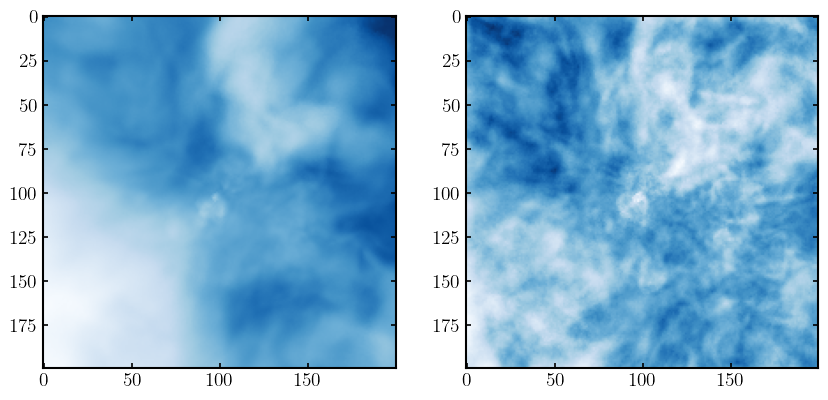

In [194]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(np.log10(struc_vel), cmap="Blues_r")
axs[1].imshow(np.log10(struc_vel_turb), cmap="Blues_r")

[0.22336215 0.18874011 0.22354279 ... 0.6600292  0.58228233 0.52851602] [0.         0.         0.         ... 0.12908365 0.16321197 0.        ]


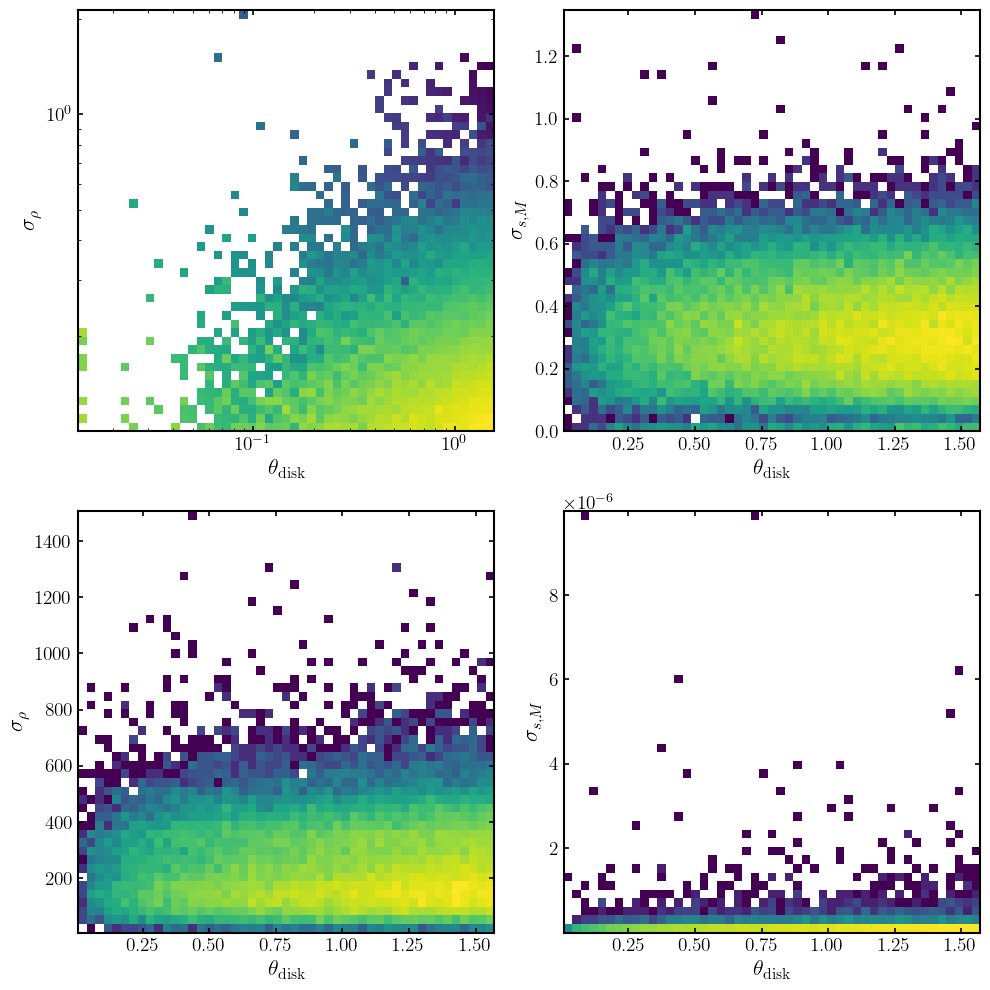

In [116]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

this_table = table_fine

Y = this_table["CompressiveMach_v"][(this_table["SFR"] == 0)]
X = np.arccos(np.abs(this_table["galactic_cos"][(this_table["SFR"] == 0)]))
# X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y) & (Y > 0.1)
print(X, Y)
X = X[mask]
Y = Y[mask]
x_bins = np.logspace(np.log10(min(X)), np.log10(max(X)), 50)
y_bins = np.logspace(np.log10(min(Y)), np.log10(max(Y)), 50)
# x_bins = np.linspace(min(X), max(X), 50)
# y_bins = np.linspace(min(Y), max(Y), 50)
axs[0, 0].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = this_table["CompressiveMach_v_turb"][(this_table["SFR"] == 0)]/this_table["Mach_v_turb"][(this_table["SFR"] == 0)]
X = np.arccos(np.abs(this_table["galactic_cos"][(this_table["SFR"] == 0)]))
# X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.linspace(min(X), max(X), 50)
y_bins = np.linspace(min(Y), max(Y), 50)
axs[0, 1].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = this_table["VelocityMean_v"][(this_table["SFR"] == 0)]
X = np.arccos(np.abs(this_table["galactic_cos"][(this_table["SFR"] == 0)]))
# X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.linspace(min(X), max(X), 50)
y_bins = np.linspace(min(Y), max(Y), 50)
axs[1, 0].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

Y = this_table["DensityMean_v"][(this_table["SFR"] == 0)]
X = np.arccos(np.abs(this_table["galactic_cos"][(this_table["SFR"] == 0)]))
# X, Y = X[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)], Y[(X < 2) & (Y < 5) & (X > 0.01) & (Y > 0.01)]
mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[mask]
Y = Y[mask]
x_bins = np.linspace(min(X), max(X), 50)
y_bins = np.linspace(min(Y), max(Y), 50)
axs[1, 1].hist2d(X, Y, bins=[x_bins, y_bins], norm="log", cmap="viridis", density=True)

axs[0, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[0, 0].set_xlabel(r"$\theta_{\mathrm{disk}}$")
axs[0, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[0, 1].set_xlabel(r"$\theta_{\mathrm{disk}}$")
axs[1, 0].set_ylabel(r"$\sigma_{\rho}$")
axs[1, 0].set_xlabel(r"$\theta_{\mathrm{disk}}$")
axs[1, 1].set_ylabel(r"$\sigma_{s, M}$")
axs[1, 1].set_xlabel(r"$\theta_{\mathrm{disk}}$")

axs[0, 0].set_xscale("log")
axs[0, 0].set_yscale("log")
# axs[0, 1].set_xscale("log")
# axs[0, 1].set_yscale("log")
# axs[1, 1].set_xscale("log")
# axs[1, 1].set_yscale("log")
# axs[1, 0].set_xscale("log")
# axs[1, 0].set_yscale("log")

fig.tight_layout()
fig.savefig("galactic_cos.pdf")